# Gán nhãn Churn 

**Dataset:** `data_v1.csv` — 64,374 khách hàng  
**Mục tiêu:** So sánh 3 phương pháp gán nhãn churn với ngưỡng dựa trên phân phối dữ liệu

| Phương pháp | Mô tả |
|---|---|
| Rule-based | Kết hợp AND/OR với ngưỡng percentile |
| Score-based | Điểm tổng hợp chuẩn hóa + trọng số correlation |
| K-Means | Phân cụm có kiểm tra và xác nhận cluster |

> **Cải tiến so với v1:** Ngưỡng dựa trên phân phối, chuẩn hóa feature, validate K-Means, kiểm tra consistency, kiểm soát imbalance, weighted consensus.

## 1. Import thư viện & đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

COLORS = {'rule':'#E24B4A', 'score':'#BA7517', 'kmeans':'#1D9E75',
          'churn':'#E24B4A', 'no_churn':'#378ADD'}

df = pd.read_csv('data_cleaned.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (64374, 15)
Columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'spend_per_tenure', 'support_rate', 'payment_risk', 'high_usage', 'recency_risk']


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,spend_per_tenure,support_rate,payment_risk,high_usage,recency_risk
0,41.0,Female,56,11,9,21.0,Premium,Quarterly,537.0,12,9.421053,0.157895,1,0,0
1,21.0,Female,35,13,0,25.0,Standard,Annual,534.0,2,14.833333,0.000000,1,0,0
2,44.0,Male,3,4,2,19.0,Basic,Monthly,534.0,9,133.500000,0.500000,0,0,0
3,37.0,Female,48,20,8,27.0,Premium,Quarterly,534.0,30,10.897959,0.163265,1,1,1
4,65.0,Male,40,4,1,8.0,Standard,Annual,214.0,27,5.219512,0.024390,0,0,1


## 2. Phân tích phân phối feature — Cơ sở chọn ngưỡng

Thay vì chọn ngưỡng cảm tính, ta dùng **thống kê mô tả** (percentile, IQR) để xác định ngưỡng có cơ sở.

In [2]:
key_features = ['Payment Delay', 'Last Interaction', 'Support Calls', 'Usage Frequency']

# Bảng thống kê
stats = df[key_features].describe(percentiles=[.25,.5,.75,.90]).T
stats['IQR'] = stats['75%'] - stats['25%']
stats['upper_fence'] = stats['75%'] + 1.5 * stats['IQR']  # outlier fence
print('Thống kê mô tả các feature chính:')
print(stats[['mean','std','25%','50%','75%','90%','upper_fence']].round(2).to_string())

# Xác định ngưỡng dựa trên phân phối
THRESH_DELAY      = df['Payment Delay'].quantile(0.75)    # top 25% delay
THRESH_RECENCY    = df['Last Interaction'].quantile(0.75) # top 25% không tương tác
THRESH_SUPPORT    = df['Support Calls'].quantile(0.75)    # top 25% gọi support
THRESH_USAGE_LOW  = df['Usage Frequency'].quantile(0.25)  # bottom 25% dùng ít

print(f'\n>>> Ngưỡng được chọn (dựa trên percentile):')
print(f'    Payment Delay    > {THRESH_DELAY:.0f}  (Q75 = top 25% trễ thanh toán)')
print(f'    Last Interaction > {THRESH_RECENCY:.0f}  (Q75 = top 25% không tương tác lâu)')
print(f'    Support Calls    > {THRESH_SUPPORT:.0f}   (Q75 = top 25% gọi nhiều nhất)')
print(f'    Usage Frequency  < {THRESH_USAGE_LOW:.0f}   (Q25 = bottom 25% dùng ít nhất)')

Thống kê mô tả các feature chính:
                   mean   std   25%   50%   75%   90%  upper_fence
Payment Delay     17.32  8.43  11.0  19.0  24.0  28.0         43.5
Last Interaction  15.50  8.64   8.0  15.0  23.0  27.0         45.5
Support Calls      5.40  3.11   3.0   6.0   8.0  10.0         15.5
Usage Frequency   15.08  8.82   7.0  15.0  23.0  27.0         47.0

>>> Ngưỡng được chọn (dựa trên percentile):
    Payment Delay    > 24  (Q75 = top 25% trễ thanh toán)
    Last Interaction > 23  (Q75 = top 25% không tương tác lâu)
    Support Calls    > 8   (Q75 = top 25% gọi nhiều nhất)
    Usage Frequency  < 7   (Q25 = bottom 25% dùng ít nhất)


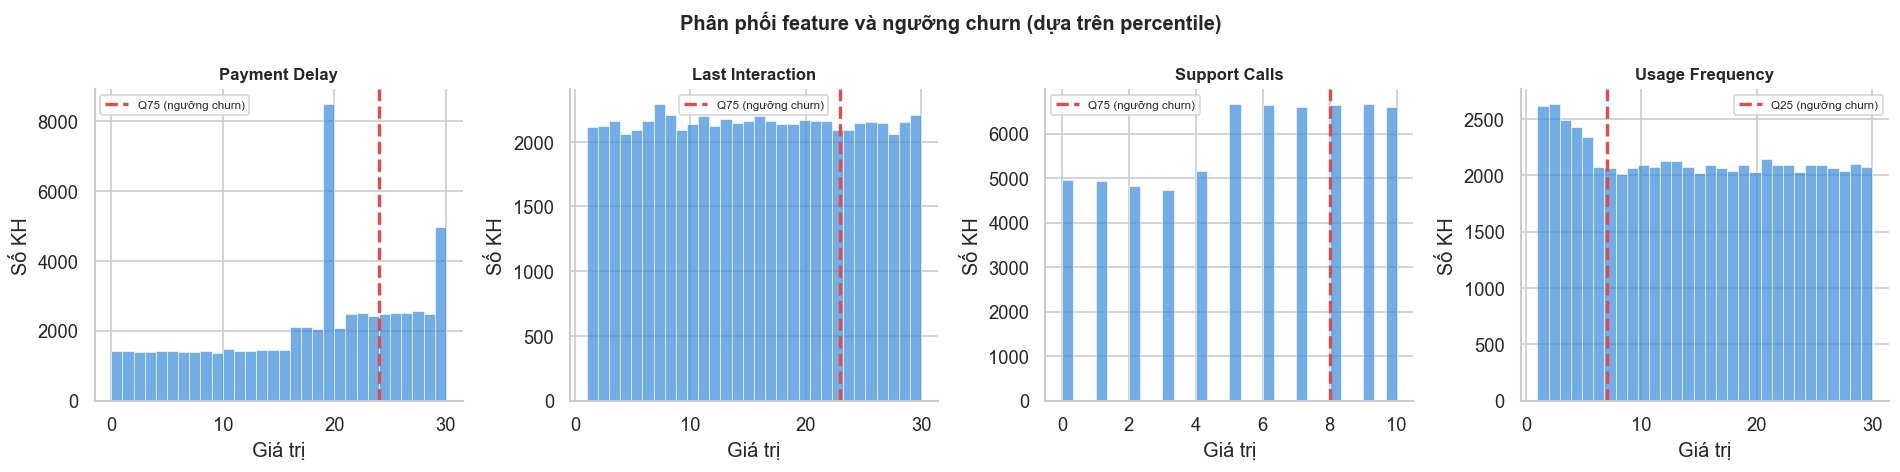

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
thresholds = [THRESH_DELAY, THRESH_RECENCY, THRESH_SUPPORT, THRESH_USAGE_LOW]
thresh_labels = ['Q75 (ngưỡng churn)', 'Q75 (ngưỡng churn)', 'Q75 (ngưỡng churn)', 'Q25 (ngưỡng churn)']

for ax, feat, thresh, tlbl in zip(axes, key_features, thresholds, thresh_labels):
    ax.hist(df[feat].dropna(), bins=30, color='#378ADD', alpha=0.7, edgecolor='white', lw=0.5)
    ax.axvline(thresh, color='#E24B4A', lw=2, linestyle='--', label=tlbl)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Giá trị'); ax.set_ylabel('Số KH')
    ax.legend(fontsize=7)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Phân phối feature và ngưỡng churn (dựa trên percentile)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Phân tích tương quan — Cơ sở chọn trọng số

Feature nào tương quan mạnh với nhiều feature churn-signal khác → được gán **trọng số cao hơn**.

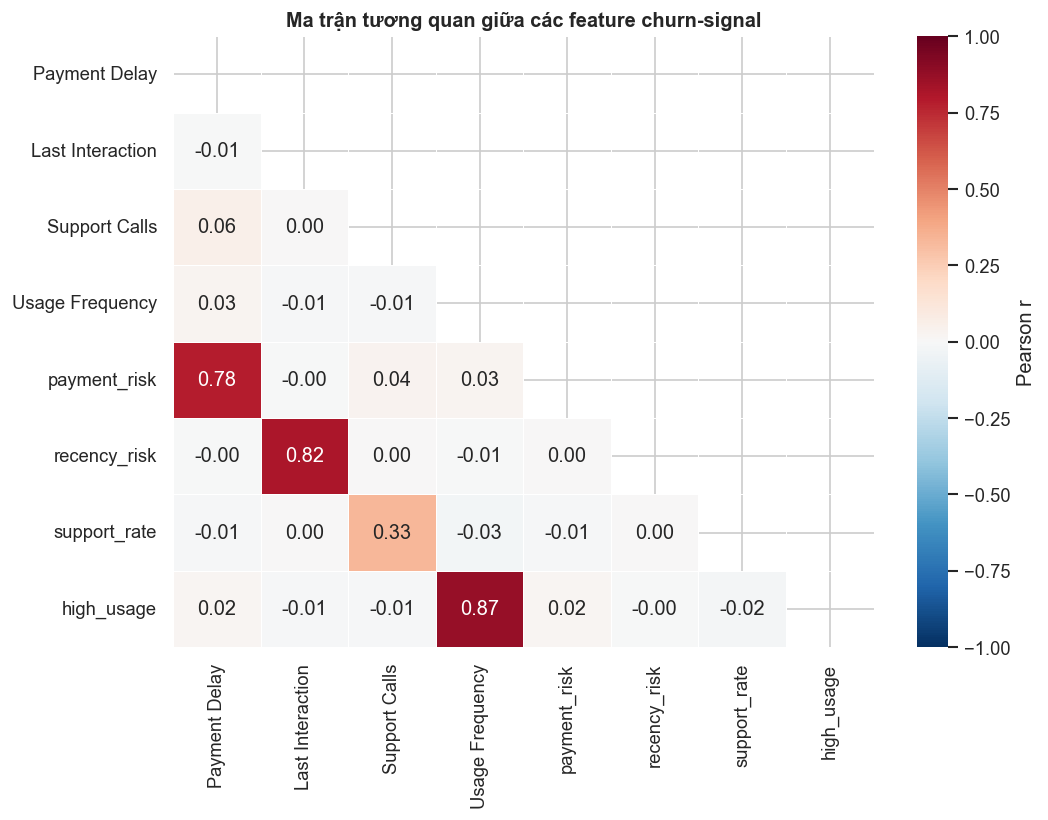

Tổng |correlation| trung bình với các feature khác (feature quan trọng hơn → trọng số cao hơn):
Usage Frequency     0.247
high_usage          0.245
Payment Delay       0.239
payment_risk        0.235
Last Interaction    0.231
recency_risk        0.229
Support Calls       0.182
support_rate        0.176
dtype: float64


In [4]:
churn_signal_features = ['Payment Delay', 'Last Interaction', 'Support Calls',
                          'Usage Frequency', 'payment_risk', 'recency_risk',
                          'support_rate', 'high_usage']

corr_matrix = df[churn_signal_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Ma trận tương quan giữa các feature churn-signal', fontweight='bold')
plt.tight_layout()
plt.show()

# Tính tổng |correlation| để xác định feature quan trọng
avg_corr = corr_matrix.abs().mean().sort_values(ascending=False)
print('Tổng |correlation| trung bình với các feature khác (feature quan trọng hơn → trọng số cao hơn):')
print(avg_corr.round(3))

## 4. Chuẩn hóa feature về [0, 1]

Trước khi tính score tổng hợp, cần **normalize** để tránh bias feature có giá trị tuyệt đối lớn.

In [5]:
score_features = ['Payment Delay', 'Last Interaction', 'Support Calls', 'Usage Frequency']

scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[score_features] = scaler.fit_transform(df[score_features])

# Usage Frequency: thấp → rủi ro cao → đảo ngược
df_norm['Usage Frequency'] = 1 - df_norm['Usage Frequency']

print('Thống kê sau chuẩn hóa (tất cả nằm trong [0,1]):')
print(df_norm[score_features].describe().round(3).to_string())

# Trọng số dựa trên avg_corr (normalize về tổng = 1)
weights_raw = avg_corr[score_features]
weights = weights_raw / weights_raw.sum()
print(f'\nTrọng số dựa trên correlation:')
for f, w in weights.items():
    print(f'    {f:20s}: {w:.3f}')
print(f'    Tổng: {weights.sum():.3f}')

Thống kê sau chuẩn hóa (tất cả nằm trong [0,1]):
       Payment Delay  Last Interaction  Support Calls  Usage Frequency
count      64374.000         64374.000      64374.000        64374.000
mean           0.577             0.500          0.540            0.514
std            0.281             0.298          0.311            0.304
min            0.000             0.000          0.000            0.000
25%            0.367             0.241          0.300            0.241
50%            0.633             0.483          0.600            0.517
75%            0.800             0.759          0.800            0.793
max            1.000             1.000          1.000            1.000

Trọng số dựa trên correlation:
    Payment Delay       : 0.266
    Last Interaction    : 0.257
    Support Calls       : 0.202
    Usage Frequency     : 0.275
    Tổng: 1.000


## 5. Phương pháp 1 — Rule-based (AND/OR logic, ngưỡng percentile)

**Logic:** Khách hàng được gán churn nếu:
- `Payment Delay > Q75` **VÀ** `Last Interaction > Q75`  
- **HOẶC** `Support Calls > Q75` (dấu hiệu mạnh, đứng độc lập)  
- **HOẶC** `Usage Frequency < Q25` **VÀ** `Payment Delay > Q75`

In [6]:
cond_delay    = df['Payment Delay']    > THRESH_DELAY
cond_recency  = df['Last Interaction'] > THRESH_RECENCY
cond_support  = df['Support Calls']    > THRESH_SUPPORT
cond_low_use  = df['Usage Frequency']  < THRESH_USAGE_LOW

df['churn_rule'] = (
    (cond_delay & cond_recency) |
    (cond_support) |
    (cond_low_use & cond_delay)
).astype(int)

n = df['churn_rule'].sum(); pct = df['churn_rule'].mean()*100
print(f'Rule-based → Churn: {n:,} ({pct:.1f}%)  |  Không churn: {len(df)-n:,} ({100-pct:.1f}%)')

# Phân tích điều kiện nào trigger nhiều nhất
print('\nSố KH trigger từng điều kiện:')
print(f'  Delay > Q75 AND Recency > Q75 : {(cond_delay & cond_recency).sum():,}')
print(f'  Support Calls > Q75            : {cond_support.sum():,}')
print(f'  Low usage AND Delay > Q75      : {(cond_low_use & cond_delay).sum():,}')

Rule-based → Churn: 17,868 (27.8%)  |  Không churn: 46,506 (72.2%)

Số KH trigger từng điều kiện:
  Delay > Q75 AND Recency > Q75 : 3,427
  Support Calls > Q75            : 13,251
  Low usage AND Delay > Q75      : 3,174


## 6. Phương pháp 2 — Score-based (chuẩn hóa + trọng số correlation)

Mean score: 0.533
Std  score: 0.151
Ngưỡng churn (mean + 0.5σ): 0.608

Score-based → Churn: 20,568 (32.0%)  |  Không churn: 43,806 (68.0%)


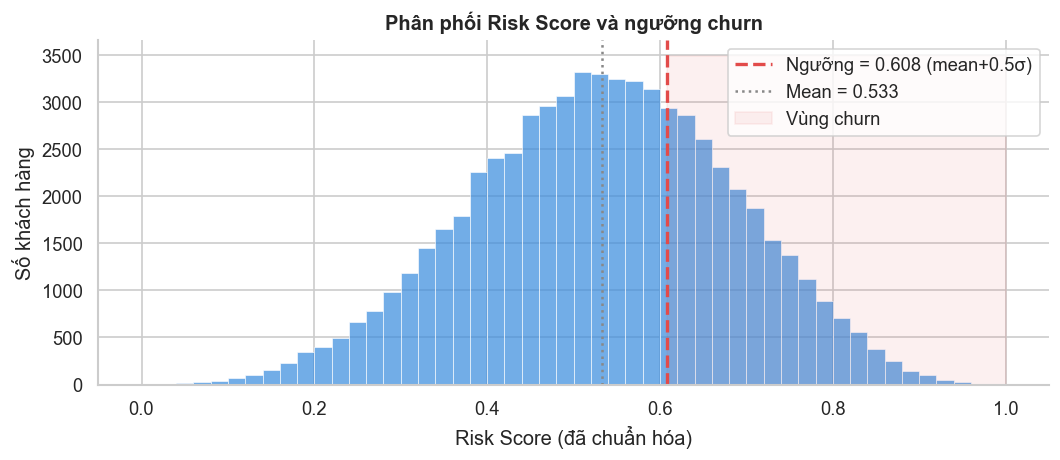

In [7]:
# Tính risk score từ feature đã chuẩn hóa
df['risk_score'] = sum(df_norm[f] * w for f, w in weights.items())

# Ngưỡng: dùng mean + 0.5*std (khách hàng trên ngưỡng = rủi ro cao)
score_thresh = df['risk_score'].mean() + 0.5 * df['risk_score'].std()
print(f'Mean score: {df["risk_score"].mean():.3f}')
print(f'Std  score: {df["risk_score"].std():.3f}')
print(f'Ngưỡng churn (mean + 0.5σ): {score_thresh:.3f}')

df['churn_score'] = (df['risk_score'] >= score_thresh).astype(int)
n = df['churn_score'].sum(); pct = df['churn_score'].mean()*100
print(f'\nScore-based → Churn: {n:,} ({pct:.1f}%)  |  Không churn: {len(df)-n:,} ({100-pct:.1f}%)')

# Trực quan phân phối score
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['risk_score'], bins=50, color='#378ADD', alpha=0.7, edgecolor='white', lw=0.5)
ax.axvline(score_thresh, color='#E24B4A', lw=2, linestyle='--', label=f'Ngưỡng = {score_thresh:.3f} (mean+0.5σ)')
ax.axvline(df['risk_score'].mean(), color='#888', lw=1.5, linestyle=':', label=f'Mean = {df["risk_score"].mean():.3f}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 5000],
                 score_thresh, df['risk_score'].max(), alpha=0.08, color='#E24B4A', label='Vùng churn')
ax.set_xlabel('Risk Score (đã chuẩn hóa)')
ax.set_ylabel('Số khách hàng')
ax.set_title('Phân phối Risk Score và ngưỡng churn', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Phương pháp 3 — K-Means (có validate cluster)

**Quy trình:**
1. Chuẩn hóa feature (StandardScaler)
2. Tìm số cluster tối ưu (Elbow + Silhouette)
3. Fit K-Means
4. **Validate** cluster bằng cách phân tích đặc trưng từng cluster
5. Gán nhãn dựa trên đặc trưng (không assume ngẫu nhiên)

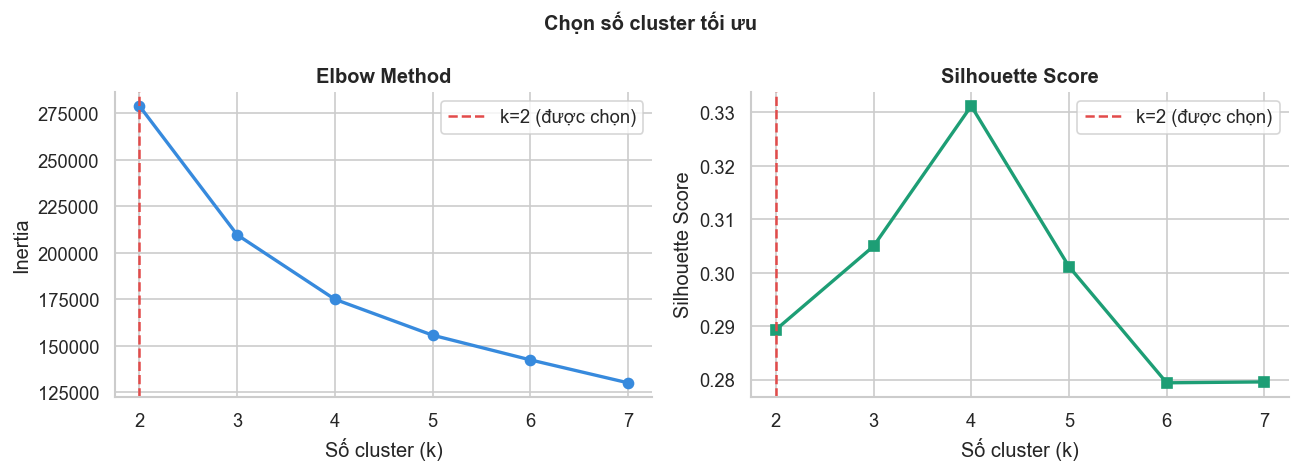

→ Chọn k=2 dựa trên Elbow + Silhouette


In [8]:
kmeans_features = ['Payment Delay', 'Last Interaction', 'Support Calls',
                   'Usage Frequency', 'payment_risk', 'recency_risk']

X = StandardScaler().fit_transform(df[kmeans_features].fillna(0))

# Elbow method + Silhouette
inertias, silhouettes = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    _km_labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, _km_labels, sample_size=5000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(k_range), inertias, 'o-', color='#378ADD', lw=2)
ax1.axvline(2, color='#E24B4A', lw=1.5, linestyle='--', label='k=2 (được chọn)')
ax1.set_xlabel('Số cluster (k)'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontweight='bold'); ax1.legend()

ax2.plot(list(k_range), silhouettes, 's-', color='#1D9E75', lw=2)
ax2.axvline(2, color='#E24B4A', lw=1.5, linestyle='--', label='k=2 (được chọn)')
ax2.set_xlabel('Số cluster (k)'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontweight='bold'); ax2.legend()

for ax in [ax1, ax2]: ax.spines[['top','right']].set_visible(False)
plt.suptitle('Chọn số cluster tối ưu', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

best_k = 2
print(f'→ Chọn k={best_k} dựa trên Elbow + Silhouette')

In [9]:
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X)

# Validate: phân tích đặc trưng từng cluster
cluster_profile = df.groupby('cluster')[kmeans_features].mean().round(2)
print('Đặc trưng trung bình từng cluster:')
print(cluster_profile.to_string())

# Chấm điểm churn cho mỗi cluster
# Dùng .iloc để tránh lỗi KeyError khi index là int
churn_score_c0 = (
    cluster_profile['Payment Delay'].iloc[0] +
    cluster_profile['Last Interaction'].iloc[0] +
    cluster_profile['payment_risk'].iloc[0] +
    cluster_profile['recency_risk'].iloc[0]
)
churn_score_c1 = (
    cluster_profile['Payment Delay'].iloc[1] +
    cluster_profile['Last Interaction'].iloc[1] +
    cluster_profile['payment_risk'].iloc[1] +
    cluster_profile['recency_risk'].iloc[1]
)
cluster_labels_idx = cluster_profile.index.tolist()
churn_cluster = cluster_labels_idx[0] if churn_score_c0 > churn_score_c1 else cluster_labels_idx[1]

print(f'\nTổng churn signal — Cluster 0: {churn_score_c0:.2f}  |  Cluster 1: {churn_score_c1:.2f}')
print(f'→ Cluster {churn_cluster} được gán nhãn CHURN')

df['churn_kmeans'] = (df['cluster'] == churn_cluster).astype(int)
n = df['churn_kmeans'].sum(); pct = df['churn_kmeans'].mean()*100
print(f'K-Means → Churn: {n:,} ({pct:.1f}%)  |  Không churn: {len(df)-n:,} ({100-pct:.1f}%)')

Đặc trưng trung bình từng cluster:
         Payment Delay  Last Interaction  Support Calls  Usage Frequency  payment_risk  recency_risk
cluster                                                                                             
0                17.29             25.51           5.41            15.01          0.42           1.0
1                17.33             10.53           5.40            15.11          0.42           0.0

Tổng churn signal — Cluster 0: 44.22  |  Cluster 1: 28.28
→ Cluster 0 được gán nhãn CHURN
K-Means → Churn: 21,361 (33.2%)  |  Không churn: 43,013 (66.8%)


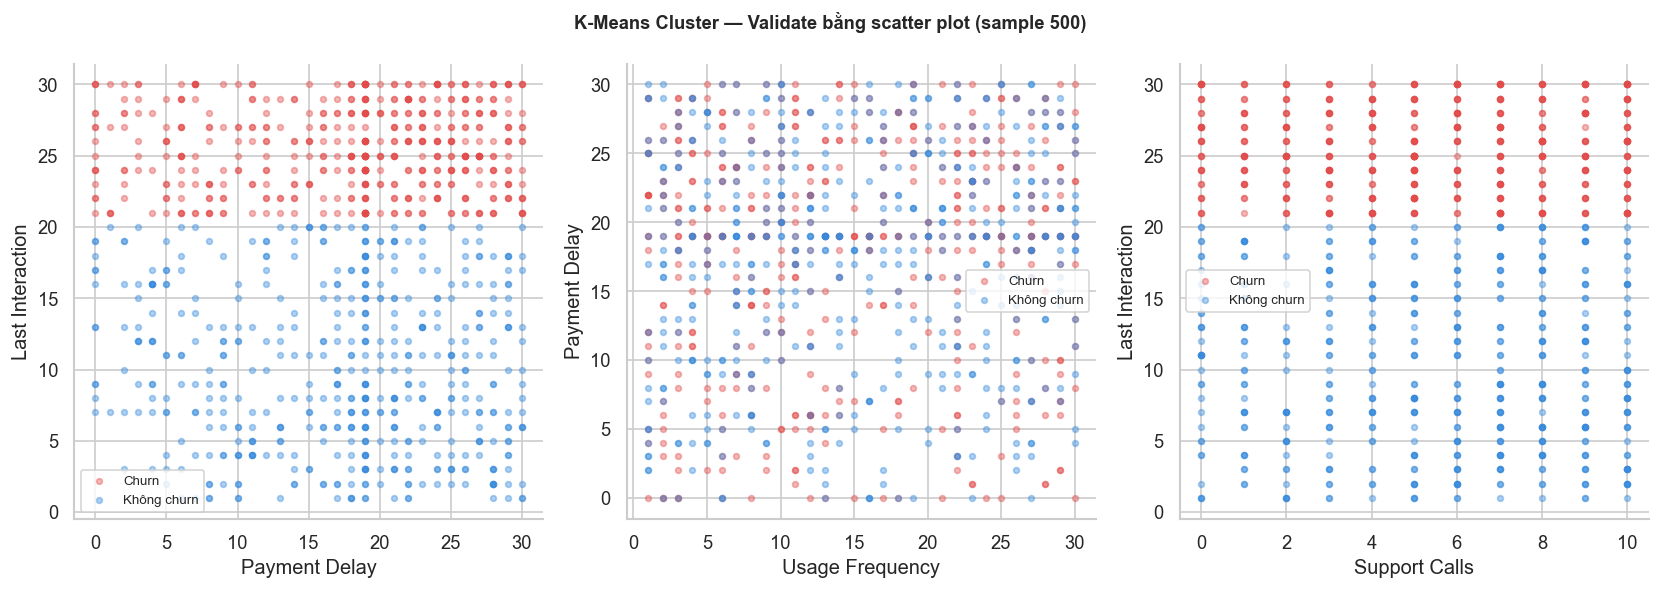

In [10]:
# Trực quan hóa cluster
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_pairs = [
    ('Payment Delay', 'Last Interaction'),
    ('Usage Frequency', 'Payment Delay'),
    ('Support Calls', 'Last Interaction'),
]
cluster_colors = {0: '#378ADD', 1: '#E24B4A'}

for ax, (fx, fy) in zip(axes, plot_pairs):
    for c in [0, 1]:
        mask = df['cluster'] == c
        label = 'Churn' if c == churn_cluster else 'Không churn'
        col = COLORS['churn'] if c == churn_cluster else COLORS['no_churn']
        ax.scatter(df.loc[mask, fx].sample(500, random_state=42),
                   df.loc[mask, fy].sample(500, random_state=42),
                   alpha=0.4, s=12, color=col, label=label)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.suptitle('K-Means Cluster — Validate bằng scatter plot (sample 500)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Kiểm tra consistency giữa các phương pháp

Phân tích mức độ đồng thuận và xung đột giữa 3 phương pháp.

In [11]:
methods = ['churn_rule', 'churn_score', 'churn_kmeans']
labels  = ['Rule-based', 'Score-based', 'K-Means']

print('=== Crosstab: Rule-based vs Score-based ===')
ct1 = pd.crosstab(df['churn_rule'], df['churn_score'],
                  rownames=['Rule'], colnames=['Score'], margins=True)
print(ct1)

print('\n=== Crosstab: Score-based vs K-Means ===')
ct2 = pd.crosstab(df['churn_score'], df['churn_kmeans'],
                  rownames=['Score'], colnames=['K-Means'], margins=True)
print(ct2)

print('\n=== Ma trận đồng thuận (%) ===')
agree_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
for m1, l1 in zip(methods, labels):
    for m2, l2 in zip(methods, labels):
        agree_matrix.loc[l1, l2] = (df[m1] == df[m2]).mean() * 100
print(agree_matrix.round(1))

=== Crosstab: Rule-based vs Score-based ===
Score      0      1    All
Rule                      
0      36939   9567  46506
1       6867  11001  17868
All    43806  20568  64374

=== Crosstab: Score-based vs K-Means ===
K-Means      0      1    All
Score                       
0        34186   9620  43806
1         8827  11741  20568
All      43013  21361  64374

=== Ma trận đồng thuận (%) ===
             Rule-based  Score-based  K-Means
Rule-based        100.0         74.5     62.0
Score-based        74.5        100.0     71.3
K-Means            62.0         71.3    100.0


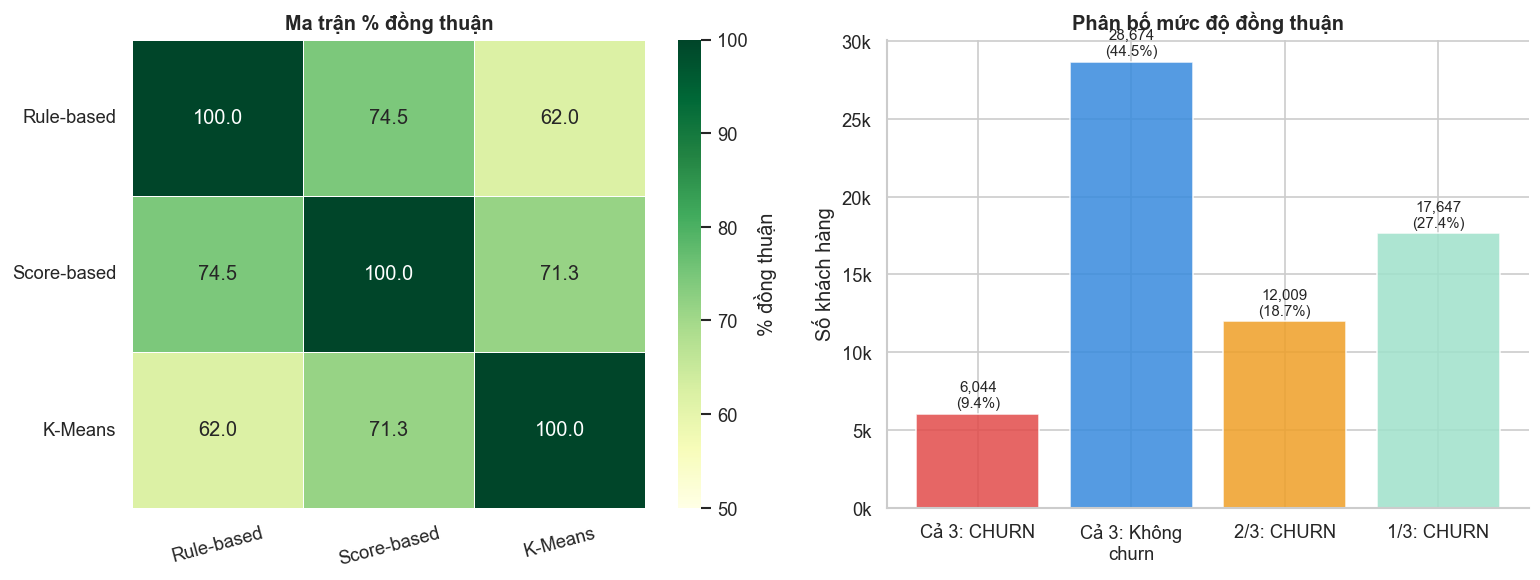

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap đồng thuận
sns.heatmap(agree_matrix.astype(float), annot=True, fmt='.1f', cmap='YlGn',
            vmin=50, vmax=100, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '% đồng thuận'})
axes[0].set_title('Ma trận % đồng thuận', fontweight='bold')
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_yticklabels(labels, rotation=0)

# Venn-like bar: 4 trạng thái
all3_churn   = ((df['churn_rule']==1)&(df['churn_score']==1)&(df['churn_kmeans']==1)).sum()
all3_no      = ((df['churn_rule']==0)&(df['churn_score']==0)&(df['churn_kmeans']==0)).sum()
only2_churn  = ((df['churn_rule']+df['churn_score']+df['churn_kmeans'])==2).sum()
only1_churn  = ((df['churn_rule']+df['churn_score']+df['churn_kmeans'])==1).sum()

cats  = ['Cả 3: CHURN', 'Cả 3: Không\nchurn', '2/3: CHURN', '1/3: CHURN']
vals  = [all3_churn, all3_no, only2_churn, only1_churn]
cols  = ['#E24B4A','#378ADD','#EF9F27','#9FE1CB']
bars = axes[1].bar(cats, vals, color=cols, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals):
    pct = v/len(df)*100
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Số khách hàng')
axes[1].set_title('Phân bố mức độ đồng thuận', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v/1000:.0f}k'))
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

## 9. Kiểm soát imbalance nhãn

Tỷ lệ churn/không-churn lý tưởng: **60/40 đến 70/30** — tránh mất cân bằng quá mức.

Tỷ lệ phân phối nhãn từng phương pháp:
Phương pháp     Churn        Không churn  Đánh giá
------------------------------------------------------------
Rule-based       27.8%        72.2%       ⚠️  Hơi lệch
Score-based      32.0%        68.0%       ✅ Cân bằng tốt
K-Means          33.2%        66.8%       ✅ Cân bằng tốt


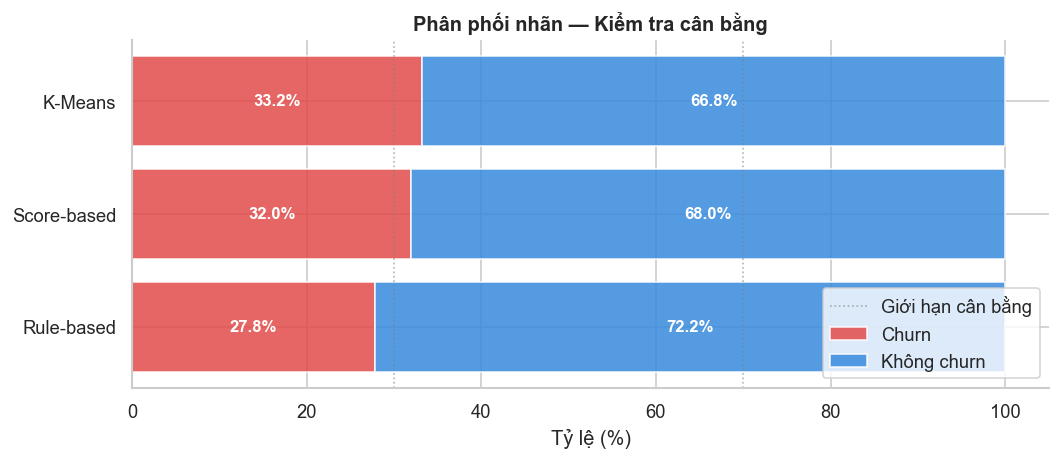

In [13]:
print('Tỷ lệ phân phối nhãn từng phương pháp:')
print(f'{"Phương pháp":<15} {"Churn":<12} {"Không churn":<12} {"Đánh giá"}')
print('-'*60)

def evaluate_balance(pct):
    if 30 <= pct <= 70: return '✅ Cân bằng tốt'
    elif 20 <= pct < 30 or 70 < pct <= 80: return '⚠️  Hơi lệch'
    else: return '❌ Mất cân bằng'

for m, lbl in zip(methods, labels):
    pct = df[m].mean()*100
    print(f'{lbl:<15} {pct:5.1f}%       {100-pct:5.1f}%       {evaluate_balance(pct)}')

# Visualize
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(labels))
churn_pcts   = [df[m].mean()*100 for m in methods]
nochurn_pcts = [100-p for p in churn_pcts]
ax.barh(x, churn_pcts,   color=COLORS['churn'],    alpha=0.85, label='Churn')
ax.barh(x, nochurn_pcts, left=churn_pcts, color=COLORS['no_churn'], alpha=0.85, label='Không churn')
for i, p in enumerate(churn_pcts):
    ax.text(p/2, i, f'{p:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(p + (100-p)/2, i, f'{100-p:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
ax.axvline(30, color='gray', lw=1, linestyle=':', alpha=0.6)
ax.axvline(70, color='gray', lw=1, linestyle=':', alpha=0.6, label='Giới hạn cân bằng')
ax.set_yticks(x); ax.set_yticklabels(labels)
ax.set_xlabel('Tỷ lệ (%)')
ax.set_title('Phân phối nhãn — Kiểm tra cân bằng', fontweight='bold')
ax.legend(loc='lower right'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 10. Phân tích chỉ số trung bình theo nhãn — Validate chất lượng nhãn

Nhãn tốt phải có sự **khác biệt rõ ràng** giữa nhóm churn và không churn.

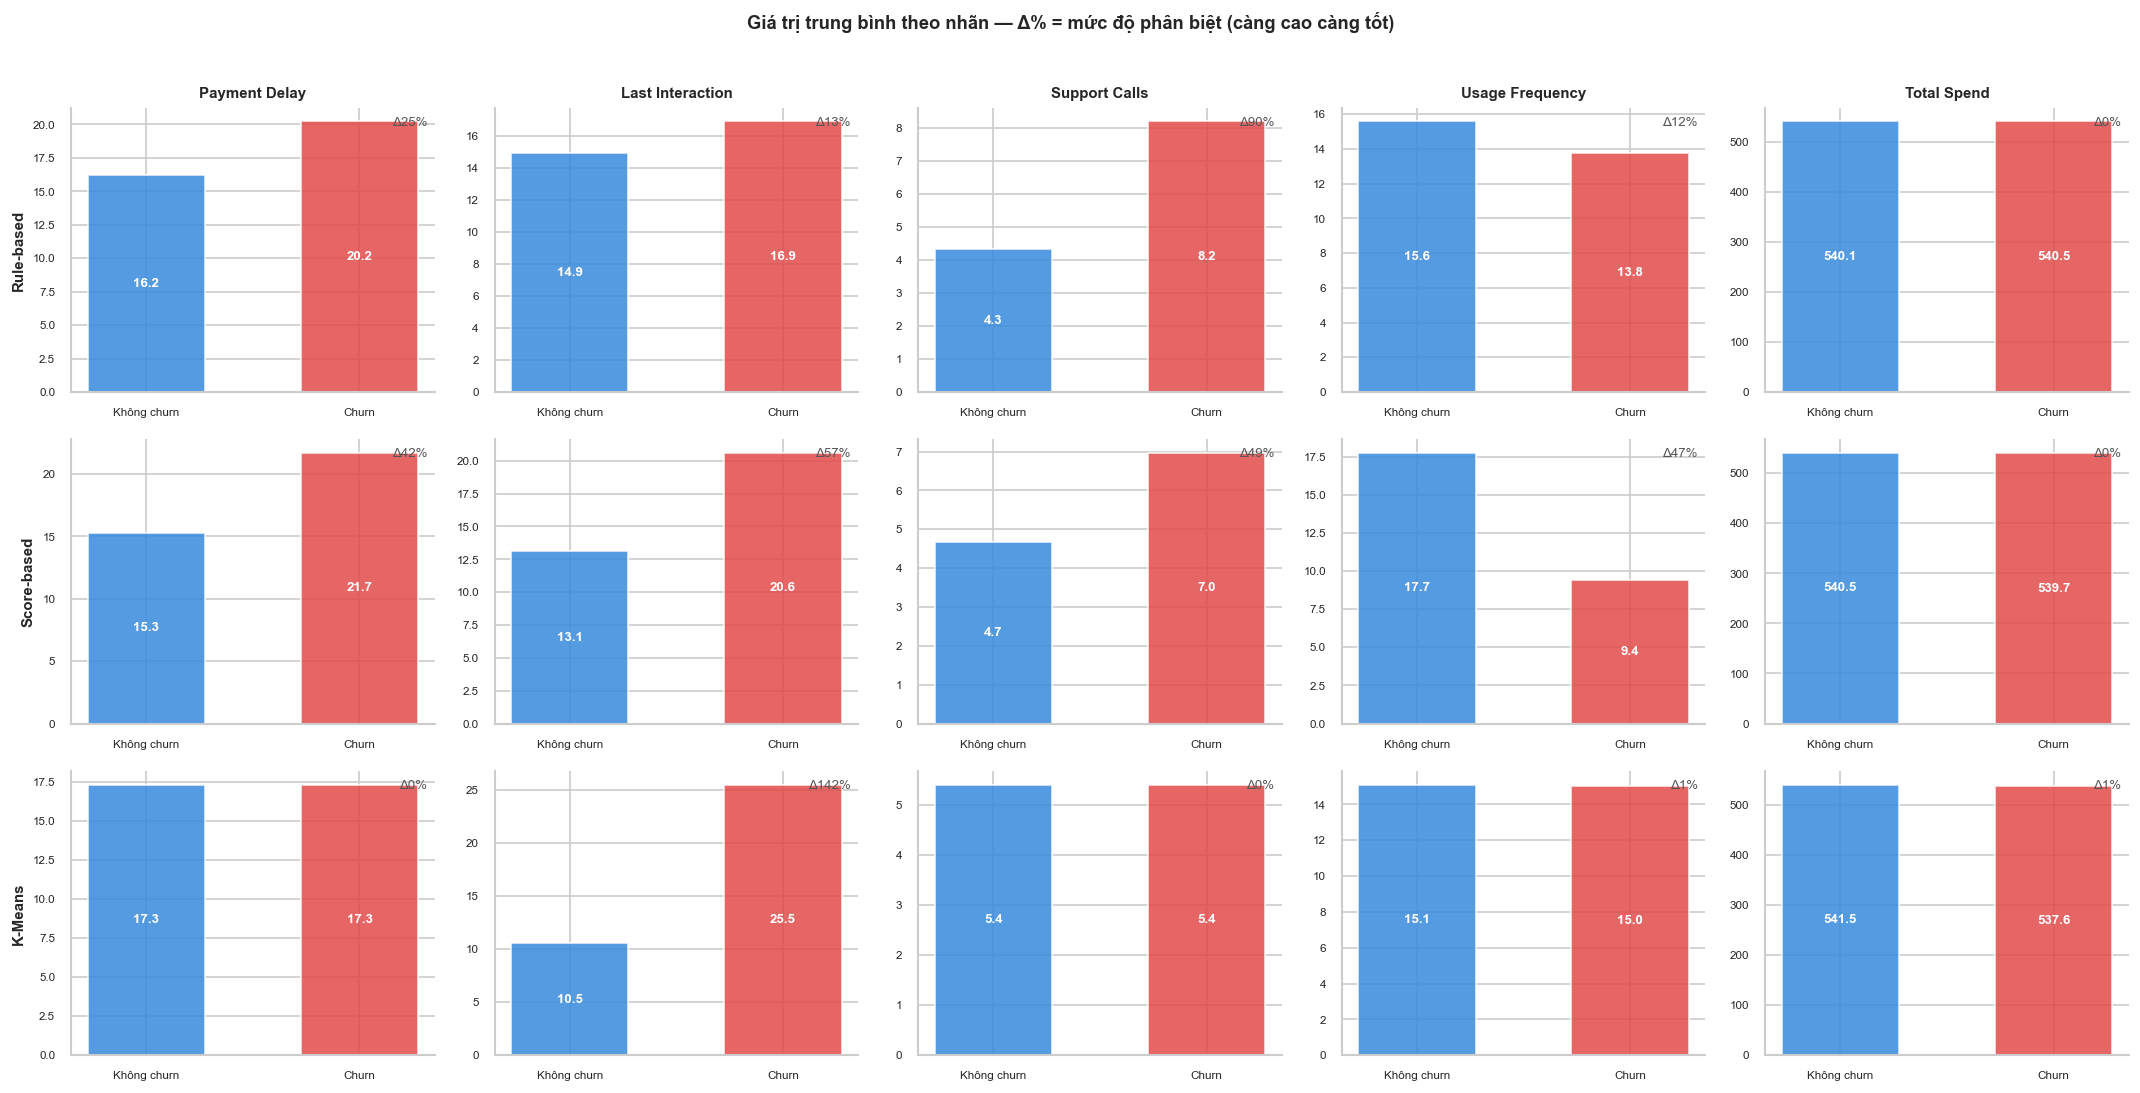

In [14]:
feat_validate = ['Payment Delay', 'Last Interaction', 'Support Calls', 'Usage Frequency', 'Total Spend']

fig, axes = plt.subplots(len(methods), len(feat_validate), figsize=(18, 9), sharey=False)

for r, (method, lbl) in enumerate(zip(methods, labels)):
    for c, feat in enumerate(feat_validate):
        ax = axes[r][c]
        g0 = df[df[method]==0][feat].mean()
        g1 = df[df[method]==1][feat].mean()
        diff_pct = abs(g1-g0)/g0*100 if g0!=0 else 0
        bar_colors = [COLORS['no_churn'], COLORS['churn']]
        bars = ax.bar(['Không churn','Churn'], [g0, g1],
                      color=bar_colors, alpha=0.85, width=0.55)
        for bar, val in zip(bars, [g0, g1]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
                    f'{val:.1f}', ha='center', va='center', color='white', fontsize=8, fontweight='bold')
        ax.set_title(feat if r==0 else '', fontsize=9, fontweight='bold')
        if c==0: ax.set_ylabel(lbl, fontsize=9, fontweight='bold')
        ax.text(0.98, 0.97, f'Δ{diff_pct:.0f}%', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#555')
        ax.tick_params(labelsize=7); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Giá trị trung bình theo nhãn — Δ% = mức độ phân biệt (càng cao càng tốt)',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 11. Nhãn tổng hợp — Weighted Consensus

Thay vì đa số đơn giản, dùng **weighted voting** ưu tiên phương pháp có cơ sở thống kê hơn.

In [15]:
# Trọng số: Score-based (có normalize + correlation) > Rule-based > KMeans
w_score  = 0.5   # cao nhất: có cơ sở thống kê
w_rule   = 0.3   # trung bình: có cơ sở percentile
w_kmeans = 0.2   # thấp nhất: unsupervised

df['consensus_weighted'] = (
    df['churn_score']  * w_score +
    df['churn_rule']   * w_rule  +
    df['churn_kmeans'] * w_kmeans
)

# Ngưỡng 0.4: ít nhất Score + 1 phương pháp khác đồng ý
df['churn_consensus'] = (df['consensus_weighted'] >= 0.4).astype(int)

n = df['churn_consensus'].sum(); pct = df['churn_consensus'].mean()*100
print(f'Weighted Consensus (ngưỡng 0.4) → Churn: {n:,} ({pct:.1f}%)  |  Không churn: {len(df)-n:,} ({100-pct:.1f}%)')
print(f'Đánh giá cân bằng: {evaluate_balance(pct)}')

# So sánh các nhãn cuối cùng
all_methods = methods + ['churn_consensus']
all_labels  = labels  + ['Weighted Consensus']
print('\nTóm tắt tỷ lệ churn tất cả phương pháp:')
for m, l in zip(all_methods, all_labels):
    n = df[m].sum(); p = df[m].mean()*100
    print(f'  {l:<22}: {n:,} ({p:.1f}%)')

Weighted Consensus (ngưỡng 0.4) → Churn: 21,923 (34.1%)  |  Không churn: 42,451 (65.9%)
Đánh giá cân bằng: ✅ Cân bằng tốt

Tóm tắt tỷ lệ churn tất cả phương pháp:
  Rule-based            : 17,868 (27.8%)
  Score-based           : 20,568 (32.0%)
  K-Means               : 21,361 (33.2%)
  Weighted Consensus    : 21,923 (34.1%)


## 12. Bảng giải thích feature theo góc độ học thuật

In [16]:
feature_explanation = pd.DataFrame({
    'Feature': ['Payment Delay', 'Last Interaction', 'Support Calls',
                'Usage Frequency', 'Total Spend'],
    'Ý nghĩa churn': [
        'Trễ thanh toán → khó khăn tài chính hoặc không còn mặn mà với dịch vụ',
        'Không tương tác lâu → engagement thấp, dấu hiệu rời bỏ',
        'Gọi support nhiều → không hài lòng, trải nghiệm kém',
        'Dùng ít → giá trị cảm nhận thấp, dễ hủy',
        'Chi tiêu thấp → khách hàng ít gắn bó, dễ rời'
    ],
    'Hướng rủi ro': ['Cao → Churn', 'Cao → Churn', 'Cao → Churn',
                     'Thấp → Churn', 'Thấp → Churn'],
    'Trọng số trong Score': [f'{weights["Payment Delay"]:.2f}',
                              f'{weights["Last Interaction"]:.2f}',
                              f'{weights["Support Calls"]:.2f}',
                              f'{weights["Usage Frequency"]:.2f}',
                              'N/A']
})
print('Giải thích feature theo góc độ học thuật:')
print(feature_explanation.to_string(index=False))

Giải thích feature theo góc độ học thuật:
         Feature                                                         Ý nghĩa churn Hướng rủi ro Trọng số trong Score
   Payment Delay Trễ thanh toán → khó khăn tài chính hoặc không còn mặn mà với dịch vụ  Cao → Churn                 0.27
Last Interaction                Không tương tác lâu → engagement thấp, dấu hiệu rời bỏ  Cao → Churn                 0.26
   Support Calls                   Gọi support nhiều → không hài lòng, trải nghiệm kém  Cao → Churn                 0.20
 Usage Frequency                               Dùng ít → giá trị cảm nhận thấp, dễ hủy Thấp → Churn                 0.27
     Total Spend                          Chi tiêu thấp → khách hàng ít gắn bó, dễ rời Thấp → Churn                  N/A


## 13. Kết luận & Xuất file

In [17]:
print('='*65)
print('TỔNG KẾT SO SÁNH PHƯƠNG PHÁP GÁN NHÃN CHURN')
print('='*65)

summary = pd.DataFrame({
    'Phương pháp': all_labels,
    'Tỷ lệ churn': [f"{df[m].mean()*100:.1f}%" for m in all_methods],
    'Số churn': [f"{df[m].sum():,}" for m in all_methods],
    'Cân bằng': [evaluate_balance(df[m].mean()*100) for m in all_methods],
    'Ưu điểm': [
        'Dễ giải thích, ngưỡng percentile có cơ sở',
        'Normalize + trọng số correlation, linh hoạt',
        'Tự học pattern, không cần định nghĩa ngưỡng',
        'Kết hợp 3 phương pháp, robust nhất'
    ]
})
print(summary.to_string(index=False))

# Xuất file
out_cols = ['Age','Gender','Tenure','Usage Frequency','Support Calls',
            'Payment Delay','Subscription Type','Contract Length',
            'Total Spend','Last Interaction','risk_score',
            'churn_consensus']
df[out_cols].to_csv('data_labeled.csv', index=False)
print('\n✓ Đã lưu: data_labeled.csv')
print('  Cột nhãn: churn_consensus (weighted consensus — phương pháp tốt nhất)')

TỔNG KẾT SO SÁNH PHƯƠNG PHÁP GÁN NHÃN CHURN
       Phương pháp Tỷ lệ churn Số churn       Cân bằng                                     Ưu điểm
        Rule-based       27.8%   17,868   ⚠️  Hơi lệch   Dễ giải thích, ngưỡng percentile có cơ sở
       Score-based       32.0%   20,568 ✅ Cân bằng tốt Normalize + trọng số correlation, linh hoạt
           K-Means       33.2%   21,361 ✅ Cân bằng tốt Tự học pattern, không cần định nghĩa ngưỡng
Weighted Consensus       34.1%   21,923 ✅ Cân bằng tốt          Kết hợp 3 phương pháp, robust nhất

✓ Đã lưu: data_labeled.csv
  Cột nhãn: churn_consensus (weighted consensus — phương pháp tốt nhất)
